# Projet d\'Apprentissage Statistique : Prédiction du Décrochage et de la Réussite Académique des Étudiants

**Auteurs :** Kardiatou THIAM/IIA & Maguette Diop/IIA

**Date :** 20 Février 2026

##1.Description du Projet

Ce projet a pour objectif de développer un modèle d\'apprentissage statistique capable de prédire le **décrochage scolaire** et la **réussite académique** des étudiants. En exploitant des données variées (démographiques, socio-économiques, académiques), nous cherchons à identifier les étudiants à risque de décrochage le plus tôt possible. Cette identification précoce permettrait aux institutions éducatives de mettre en place des interventions ciblées et personnalisées, contribuant ainsi à améliorer les taux de rétention et de diplomation. Il s\'agit fondamentalement d\'un problème de **classification multi-classes**, où le modèle devra distinguer entre les étudiants qui **décrochent**, ceux qui **restent inscrits** et ceux qui **obtiennent leur diplôme**.

## 2.Objectifs du Projet

### 2.1. Objectif Principal

Développer un modèle de classification robuste et interprétable capable de prédire l\'état final d\'un étudiant (décrocheur, inscrit, diplômé) avec une précision élevée, en se basant sur les informations disponibles au moment de son inscription ou en début de parcours.

### 2.2. Objectifs Secondaires

*   **Identification des facteurs clés** : Déterminer les variables (démographiques, socio-économiques, académiques) qui influencent le plus le risque de décrochage ou la probabilité de réussite.
*   **Évaluation des performances** : Mesurer l\'efficacité du modèle à l\'aide de métriques de classification appropriées (précision, rappel, F1-score, AUC) et analyser ses performances pour chaque classe, en particulier pour la classe minoritaire de décrochage.
*   **Analyse des limites et pistes d\'amélioration** : Discuter des conditions dans lesquelles le modèle fonctionne le mieux et celles où il échoue, et proposer des stratégies pour enrichir les données ou améliorer le modèle.

### 2.3. Qu\'est-ce qui constituerait une bonne solution ou un bon résultat ?

Une bonne solution se caractériserait par un modèle qui non seulement atteint une **haute précision globale**, mais qui excelle également à identifier correctement les étudiants à risque de décrochage (haut **rappel** pour la classe \'décrocheur\') afin de minimiser les faux négatifs. L\'**interprétabilité** du modèle est également cruciale pour comprendre les raisons sous-jacentes aux prédictions et pour guider les actions pédagogiques. Enfin, une **analyse critique** des résultats, incluant les limites du modèle et des suggestions concrètes pour son amélioration (notamment via l\'enrichissement des données), sera un indicateur clé de la qualité du projet.

### 2.4. Comment prévoyez-vous vous y prendre ?

Nous allons suivre une méthodologie structurée :
1.  **Collecte et chargement des données** : Utilisation du dataset Kaggle spécifié.
2.  **Exploration et analyse préliminaire des données (EDA)** : Comprendre la structure, les types de variables, les distributions et identifier les problèmes (valeurs manquantes, outliers, déséquilibre des classes).
3.  **Prétraitement des données** : Nettoyage, gestion des valeurs manquantes, encodage des variables catégorielles, normalisation/standardisation des variables numériques.
4.  **Gestion du déséquilibre des classes** : Application de techniques de suréchantillonnage (SMOTE) ou de sous-échantillonnage si nécessaire.
5.  **Sélection et entraînement du modèle** : Choix du Random Forest pour sa robustesse et son interprétabilité.
6.  **Évaluation du modèle** : Utilisation de métriques de classification et d\'outils de visualisation (matrice de confusion, rapport de classification, courbe ROC).
7.  **Analyse d\'interprétabilité** : Étude de l\'importance des caractéristiques pour comprendre les facteurs influents.
8.  **Discussion et conclusion** : Synthèse des résultats, identification des limites et proposition de pistes d\'amélioration.

## 3.Description des Données

### 3.1. Chargement des Bibliothèques Nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

###3.2. Chargement du Dataset
Le dataset utilisé est "Predict Students' Dropout and Academic Success" disponible sur Kaggle [1]. Il provient d'un établissement d'enseignement supérieur portugais et a été élaboré dans le cadre d'un projet national visant à lutter contre le décrochage scolaire et l'échec universitaire. Pour télécharger ce dataset, vous devrez avoir un compte Kaggle et utiliser l'API Kaggle ou le télécharger manuellement. Pour l'exécution dans Google Colab, il est courant de monter Google Drive ou de télécharger le fichier directement.
Instructions pour télécharger le dataset sur Colab :
Allez sur la page Kaggle du dataset : https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success
Cliquez sur le bouton 'Download'.
Uploadez le fichier student_dropout_and_academic_success.csv dans votre environnement Colab (par exemple, dans le dossier /content/).

In [2]:
# Chemin vers le fichier CSV du dataset
data_path = "students_dropout_academic_success.csv"

try:
    df = pd.read_csv(data_path)
    print("Dataset chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier {data_path} n'a pas été trouvé. Veuillez vous assurer qu'il est bien téléchargé et placé au bon endroit.")
    print("Veuillez suivre les instructions pour télécharger le dataset depuis Kaggle.")
    # Créer un DataFrame vide ou un exemple pour permettre au code de s'exécuter sans erreur si le fichier est manquant
    # Pour une exécution complète, le fichier est indispensable.
    df = pd.DataFrame()


Dataset chargé avec succès.


####Affichage des premières lignes du dataset

In [3]:
# Affichage des premières lignes du dataset
if not df.empty:
    print("\\nPremières lignes du dataset :")
    print(df.head())

\nPremières lignes du dataset :
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2     

###3.3. Exploration Préliminaire des Données

In [4]:
if not df.empty:
    print("\\nInformations générales sur le dataset :")
    print(df.info())


\nInformations générales sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9  

####Statistiques descriptives

In [5]:
print("\\nStatistiques descriptives :")
print(df.describe())

\nStatistiques descriptives :
       Marital Status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000                1

####Nombre de Valeurs manquantes par colonne

In [6]:
print("\\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

\nNombre de valeurs manquantes par colonne :
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder 

####Distribution de la variable cible

\nDistribution de la variable cible ('target') :
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


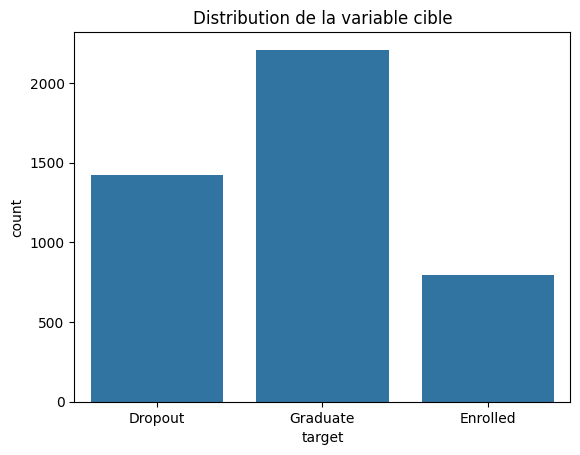

In [7]:
print("\\nDistribution de la variable cible (\'target\') :")
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Distribution de la variable cible')
plt.show()

###3.4. Types d'Attributs et Propriétés Statistiques
Le dataset contient un mélange d'attributs numériques et catégoriels. La variable cible est Target, qui indique l'état final de l'étudiant (Dropout, Enrolled, Graduate).
**Exemples de types d'attributs** :
* **Démographiques** : Marital Status, Application Mode, Daytime/evening attendance.
* **Socio-économiques** : Scholarship holder, Tuition fees up to date, Debtor.
* **Académiques** : Curricular units 1st sem (approved), Curricular units 1st sem (grade), Admission grade.

###3.5. Difficultés Potentielles et Stratégies
* **Informations manquantes** : L'exploration initiale (df.isnull().sum()) montre que toutes les variables présentent 0 valeurs manquantes.
Cela signifie que le jeu de données est complet et qu’aucune opération d’imputation ou de suppression de données n’a été nécessaire.
* **Déséquilibre des classes** : La distribution de la variable Target peut montrer un déséquilibre (par exemple, moins de 'Dropout' que de 'Graduate'). Cela peut biaiser le modèle. Nous utiliserons SMOTE (Synthetic Minority Over-sampling Technique) pour suréchantillonner les classes minoritaires et équilibrer le dataset d'entraînement.
* **Corrélation entre attributs** : Une matrice de corrélation (df.corr()) peut révéler des attributs fortement corrélés. Pour le Random Forest, cela est moins problématique que pour d'autres modèles (comme la régression linéaire), mais une analyse peut aider à la compréhension.
* **Encodage des variables catégorielles** : Les algorithmes d'apprentissage automatique nécessitent des entrées numériques. Les variables catégorielles seront encodées à l'aide de OneHotEncoder.
* **Mise à l'échelle des variables numériques** : StandardScaler sera appliqué aux variables numériques pour les mettre à la même échelle, ce qui est bénéfique pour de nombreux algorithmes et pipelines.

###3.6. Informations Manquantes et Enrichissement des Données
Le dataset actuel est riche, mais pour aller plus loin, les informations suivantes seraient précieuses :
* **Données comportementales** : Fréquence de connexion à la plateforme d'apprentissage (LMS), participation aux forums, temps passé sur les ressources de cours. Ces données pourraient être extraites des journaux d'activité du LMS.
* **Données contextuelles de l'établissement** : Taille des classes, ratio professeurs/étudiants, ressources de soutien disponibles. Ces informations pourraient être collectées auprès de l'administration universitaire via des requêtes SQL ou des exports de bases de données.
* **Données géospatiales** : Distance entre le domicile de l'étudiant et l'université. Peut être obtenue via des APIs de géocodage (ex: Google Maps API) en utilisant les adresses des étudiants (si disponibles et anonymisées).
Ces jeux de données pourraient être fusionnés avec le dataset principal en utilisant un identifiant étudiant commun. La structuration se ferait en DataFrames Pandas, stockés idéalement dans une base de données ou des fichiers Parquet pour l'efficacité, et chargés en mémoire au besoin.

###3.7. Procédure de Tests
Nous diviserons le dataset en un ensemble d'entraînement (80%) et un ensemble de test (20%) pour évaluer la généralisation du modèle. Une validation croisée (k-fold cross-validation) sera utilisée sur l'ensemble d'entraînement pour une évaluation plus robuste des hyperparamètres et des performances du modèle.

## 4.Traitement des Données : Choix de l\'Algorithme et Implémentation

### 4.1. Algorithme Choisi : Random Forest Classifier

Nous avons choisi d\'implémenter un algorithme de **Random Forest (Forêt Aléatoire)** pour ce projet de classification. Le Random Forest est un algorithme d\'apprentissage ensembliste qui combine les prédictions de plusieurs arbres de décision pour obtenir un résultat plus précis et stable.

**Fonctionnement Technique et Composantes Clés :**

1.  **Bagging (Bootstrap Aggregating)** : Le Random Forest construit plusieurs arbres de décision. Chaque arbre est entraîné sur un sous-échantillon du dataset d\'entraînement, tiré avec remplacement (bootstrap). Cela signifie que certains échantillons peuvent être sélectionnés plusieurs fois, tandis que d\'autres ne le sont pas du tout.
2.  **Sélection aléatoire des caractéristiques** : Lors de la construction de chaque arbre, à chaque nœud, un sous-ensemble aléatoire de caractéristiques est sélectionné pour trouver la meilleure division. Cette aléatorisation réduit la corrélation entre les arbres et augmente la diversité de l\'ensemble.
3.  **Agrégation des prédictions** : Pour un problème de classification, la prédiction finale du Random Forest est obtenue par un vote majoritaire des prédictions de tous les arbres individuels. Pour la régression, c\'est la moyenne des prédictions.

### 4.2. Justification du Choix

Le Random Forest est un excellent choix pour ce projet pour les raisons suivantes :

*   **Robustesse au surapprentissage** : Contrairement aux arbres de décision individuels qui peuvent facilement surapprendre, le Random Forest, grâce à l\'agrégation et à la randomisation, est beaucoup plus robuste et généralise bien sur de nouvelles données.
*   **Bonnes performances** : Il est réputé pour offrir de très bonnes performances sur une large gamme de problèmes de classification et de régression, y compris sur des datasets avec un mélange de variables numériques et catégorielles.
*   **Gestion des variables** : Il gère naturellement les deux types de variables (numériques et catégorielles) sans nécessiter un encodage complexe des variables catégorielles (bien que le prétraitement reste une bonne pratique).
*   **Importance des caractéristiques** : Le Random Forest permet d\'évaluer l\'importance relative de chaque caractéristique dans la prédiction. Cette fonctionnalité est cruciale pour l\'interprétabilité du modèle, car elle nous aide à identifier les facteurs les plus influents sur le décrochage ou la réussite des étudiants.
*   **Alternatives considérées** : Nous avons envisagé d\'autres algorithmes comme la Régression Logistique (souvent trop simple pour capturer les relations complexes), les Machines à Vecteurs de Support (SVM) (moins interprétables et sensibles à la mise à l\'échelle), et le Gradient Boosting (souvent très performant mais plus complexe à optimiser et potentiellement plus sujet au surapprentissage si mal paramétré). Le Random Forest offre un excellent compromis entre performance, robustesse, facilité d\'utilisation et interprétabilité pour ce type de problème.

### 4.3. Implémentation du Pipeline de Prétraitement et du Modèle

####Séparation des caractéristiques (X) et de la variable cible (y)

In [8]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

if not df.empty:
# Séparation des caractéristiques (X) et de la variable cible (y)
    X = df.drop('target', axis=1)
    y = df['target']

####Division du dataset en ensembles d\'entraînement et de test

In [9]:
# Division du dataset en ensembles d\'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
)

####Identification des colonnes numériques et catégorielles

In [10]:
# Identification des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

####Création des pipelines de prétraitement

In [11]:
# Création des pipelines de prétraitement
numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

####Fusion des transformations

In [12]:
# Combinaison des pipelines de prétraitement
preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

####Construction du Pipeline global(Preprocessing + SMOTE + Random Forest)

In [13]:
#  Pipeline complet AVEC SMOTE dedans
model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

####Recherche d'hyperparamètres (GridSearchCV) et Optimisation du modèle


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score F1-macro :", grid_search.best_score_)

# On remplace le modèle par le meilleur
model_pipeline = grid_search.best_estimator_

Meilleurs paramètres : {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Meilleur score F1-macro : 0.7138123145024701


####Validation croisée

In [15]:
#VALIDATION CROISEE
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("Scores F1-macro en validation croisée :", cv_scores)
print("F1-macro moyen :", cv_scores.mean())


Scores F1-macro en validation croisée : [0.6976698  0.70803684 0.7085512  0.72458234 0.72074778]
F1-macro moyen : 0.7119175931039364


###4.4 Comparaison avec Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

log_pipeline = Pipeline(steps=[
    ('preprocessor', model_pipeline.named_steps['preprocessor']),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Validation croisée pour Logistic Regression
log_scores = cross_val_score(
    log_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

# Validation croisée pour Random Forest optimisé
rf_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("F1-macro moyen Random Forest :", rf_scores.mean())
print("F1-macro moyen Logistic Regression :", log_scores.mean())


F1-macro moyen Random Forest : 0.7119175931039364
F1-macro moyen Logistic Regression : 0.7046863831672696


###4.5 Comparaison des Modèles : Random Forest vs Régression Logistique

Afin d’évaluer la robustesse du modèle principal, une comparaison a été effectuée entre le Random Forest et la Régression Logistique en utilisant une validation croisée à 5 plis avec la métrique F1-macro.

 **Pourquoi comparer ?**

La Régression Logistique est un modèle linéaire simple, souvent utilisé comme modèle de référence (baseline).
Le Random Forest, quant à lui, est un modèle non linéaire capable de capturer des interactions complexes entre variables.

 **Comparer les deux permet de** :

Vérifier si la complexité du Random Forest est réellement justifiée

Évaluer si un modèle plus simple pourrait suffire

Garantir la robustesse scientifique du choix final

 **Résultats obtenus**

 Modèle             F1-macro moyen (validation croisée)

Random Forest         0.7119175931039364

Régression Logistique   0.7046863831672696

**Analyse des résultats**

Les performances similaires indiquent que les relations dans les données peuvent être relativement linéaires. Dans ce cas, la Régression Logistique, plus simple et plus interprétable, pourrait constituer une alternative intéressante.

 **Choix du modèle final**

Au regard des résultats obtenus, le modèle retenu pour l’évaluation finale sur l’ensemble de test est :

 Random Forest

**Ce choix repose sur** :

Sa performance moyenne en validation croisée

Sa capacité à gérer le déséquilibre de classes

Sa robustesse globale

 **Discussion méthodologique**

La comparaison met en évidence l’importance de ne pas se limiter à un seul modèle.
En apprentissage automatique, un modèle plus complexe n’est pas nécessairement meilleur. La validation croisée permet de garantir que les performances observées ne sont pas dues au hasard ou à une configuration particulière des données.

## 5.Résultat Final et Analyse


### 5.1. Évaluation Complète (Rapport, Matrice, ROC/AUC et Importance) du Modèle sur l'Ensemble de Test

####Prediction du modèle

In [17]:
if not df.empty:
# Prédictions (le pipeline applique preprocessing + SMOTE automatiquement)
  y_pred = model_pipeline.predict(X_test)
  y_pred_proba = model_pipeline.predict_proba(X_test)

####Rapport de Classification

In [18]:
# Rapport de Classification
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))


--- Rapport de Classification ---
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.78       284
    Enrolled       0.53      0.52      0.52       159
    Graduate       0.83      0.89      0.86       442

    accuracy                           0.77       885
   macro avg       0.73      0.71      0.72       885
weighted avg       0.77      0.77      0.77       885



####Balanced Accuracy

In [19]:
# Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy :", balanced_acc)

Balanced Accuracy : 0.7148503254746709


 #### Matrice de Confusion


--- Matrice de Confusion ---


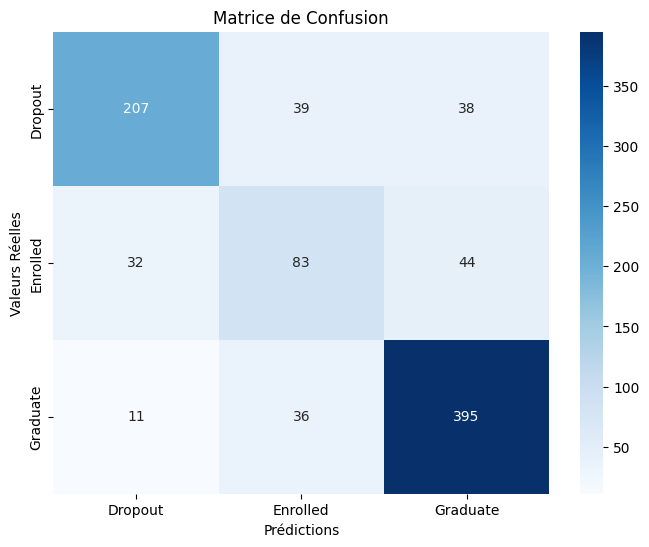

In [20]:
# Matrice de Confusion
print("\n--- Matrice de Confusion ---")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=model_pipeline.named_steps['classifier'].classes_,
        yticklabels=model_pipeline.named_steps['classifier'].classes_
    )

plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.title("Matrice de Confusion")
plt.show()

#### Courbes ROC multi-classes


--- Scores ROC AUC (One-vs-Rest) ---
AUC pour la classe 'Dropout' : 0.9083
AUC pour la classe 'Enrolled' : 0.8201
AUC pour la classe 'Graduate' : 0.9293


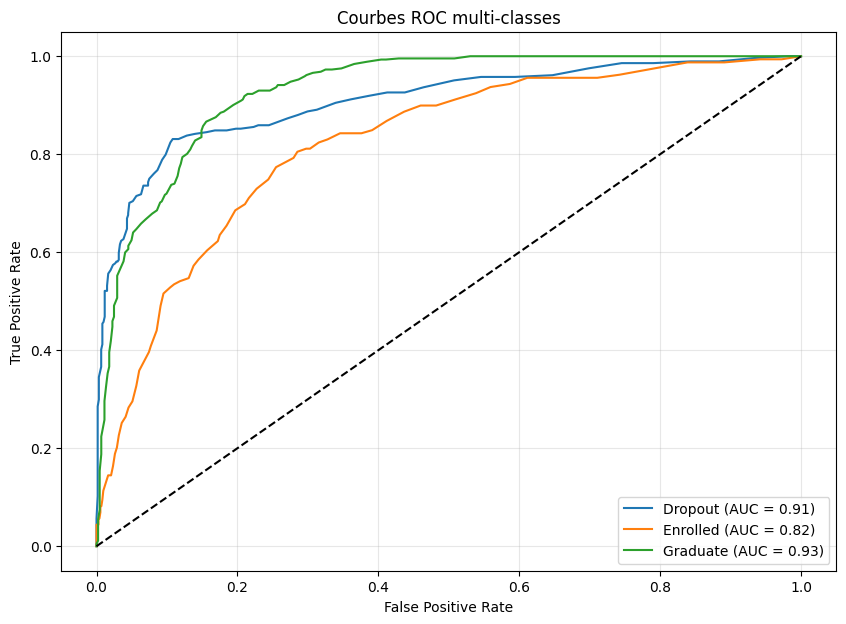

In [21]:
#   Courbes ROC multi-classes (One-vs-Rest)
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, roc_auc_score

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
classes = model_pipeline.named_steps['classifier'].classes_

plt.figure(figsize=(10, 7))
print("\n--- Scores ROC AUC (One-vs-Rest) ---")

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])

    print(f"AUC pour la classe '{class_name}' : {auc_score:.4f}")
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC multi-classes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Importance des Variables (Random Forest)

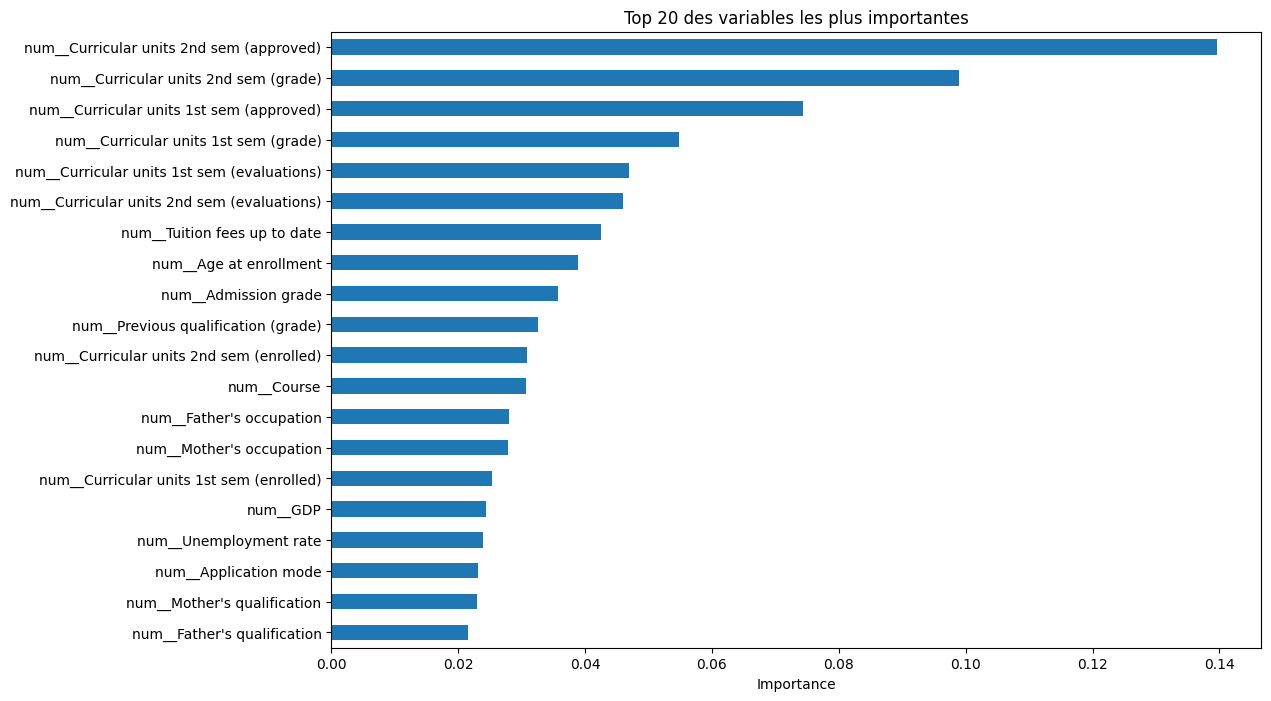

In [22]:
# Importance des variables (Random Forest uniquement)
classifier = model_pipeline.named_steps['classifier']
if hasattr(classifier, "feature_importances_"):

# Récupération automatique des noms de variables après preprocessing
  feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

  importances = classifier.feature_importances_

  feature_importances = pd.Series(importances, index=feature_names)

  plt.figure(figsize=(12, 8))
  feature_importances.nlargest(20).plot(kind='barh')
  plt.gca().invert_yaxis()
  plt.title("Top 20 des variables les plus importantes")
  plt.xlabel("Importance")
  plt.show()

else:
  print("Ce modèle ne fournit pas d'importance des variables.")


###5.2. Analyse Détaillée des Résultats
Le **rapport de classification** fournit une vue d'ensemble des performances du modèle pour chaque classe. Il est crucial d'examiner la **précision**, le **rappel** et le **F1-score** pour les classes 'Dropout', 'Enrolled' et 'Graduate'. Un rappel élevé pour la classe 'Dropout' est particulièrement important, car il indique la capacité du modèle à identifier correctement les étudiants à risque, minimisant ainsi les faux négatifs (étudiants à risque non identifiés).

La **matrice de confusion** permet de visualiser les erreurs spécifiques du modèle : combien d'étudiants 'Dropout' ont été prédits comme 'Enrolled' ou 'Graduate', et vice-versa. Cela aide à comprendre les biais du modèle et les confusions qu'il fait entre les classes.

Les **courbes ROC et les scores AUC** (Area Under the Curve) pour chaque classe (approche One-vs-Rest) évaluent la capacité du modèle à distinguer une classe des autres. Un AUC proche de 1 indique une excellente capacité de discrimination.

L'**importance des caractéristiques** est un aspect clé de l"interprétabilité du Random Forest. En analysant les 20 caractéristiques les plus importantes, nous pouvons identifier les facteurs qui contribuent le plus à la prédiction du décrochage ou de la réussite. Par exemple, des notes faibles au premier semestre, un statut de boursier, ou des difficultés financières pourraient émerger comme des prédicteurs majeurs.

**Conditions idéales et échecs** :
* Le modèle devrait bien fonctionner pour les étudiants ayant des profils très clairs (par exemple, de très bonnes notes et un soutien financier stable pour les 'Graduate', ou des échecs répétés et des difficultés socio-économiques pour les 'Dropout').
* Il pourrait échouer pour les cas limites ou ambigus, où les facteurs de risque et de succès sont mélangés, ou pour des étudiants dont le comportement ne correspond pas aux schémas appris (par exemple, un étudiant brillant qui décroche pour des raisons personnelles non capturées par les données).

**Analyse par classe/attribut** :
* Si le rappel pour la classe 'Dropout' est faible, cela signifie que le modèle manque de nombreux étudiants à risque. Cela pourrait être dû à un déséquilibre de classe persistant (même après SMOTE) ou à un manque de caractéristiques discriminantes pour cette classe.
* Les attributs liés aux performances académiques du premier semestre (Curricular units 1st sem (approved), Curricular units 1st sem (grade)) sont souvent très prédictifs. Si d'autres attributs (socio-économiques, démographiques) apparaissent également dans le top des importances, cela renforce la compréhension des facteurs de risque.

**Temps de calcul et complexité** :
Le Random Forest est généralement efficace en termes de temps d'entraînement et de prédiction, surtout avec un nombre modéré d'arbres. Sa complexité est principalement liée au nombre d'arbres et à la profondeur de chaque arbre. Pour ce projet, le temps de calcul devrait être raisonnable sur Google Colab.

##6.Conclusion et Perspectives
Ce projet a permis de construire un modèle de prédiction du décrochage et de la réussite académique des étudiants en utilisant le Random Forest. L'analyse des résultats, incluant les métriques de performance et l'importance des caractéristiques, offre des insights précieux pour les institutions éducatives.
* **Pistes d'amélioration** :
Enrichissement des données : Intégrer les données comportementales du LMS et les données contextuelles de l'établissement pour améliorer la puissance prédictive du modèle.
* **Comparaison d'algorithmes** : Tester d'autres algorithmes (Gradient Boosting, SVM, réseaux de neurones) et comparer leurs performances pour identifier le modèle le plus adapté.
* **Interprétabilité avancée** : Utiliser des outils comme SHAP (SHapley Additive exPlanations) pour une interprétabilité locale des prédictions du modèle.

Ce projet démontre l'application de l'apprentissage statistique à un problème réel et complexe, avec un potentiel d'impact significatif sur le soutien aux étudiants.

##7.Références
[1]https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success "Predict Students\" Dropout and Academic Success. Kaggle. Disponible sur :kaggle"